In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -q --upgrade transformers==4.45.2 accelerate sentencepiece
!pip install -q sentence-transformers qwen-vl-utils

In [3]:
import os
import re
import gc
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

import torch
from transformers import (
    AutoConfig,
    AutoModelForCausalLM,
    AutoProcessor,
    Qwen2VLForConditionalGeneration,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

CSV_PATH = "/kaggle/working/vqa_dataset_test_mapped.csv"
OUTPUT_DIR = "/kaggle/working/vlm_day_night_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAMPLE_PER_CATEGORY_PER_LIGHT = 100

MODEL_IDS = {
    "phi3": "microsoft/Phi-3.5-vision-instruct",
    "qwen2vl": "Qwen/Qwen2-VL-2B-Instruct",
}

print("DEVICE:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

2026-04-18 12:00:24.190486: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776513624.214673     705 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776513624.222728     705 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776513624.243389     705 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776513624.243405     705 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776513624.243408     705 computation_placer.cc:177] computation placer alr

DEVICE: cuda
GPU: Tesla T4


In [4]:
if not os.path.exists("/kaggle/working/roadscapes_data"):
    !git clone https://github.com/roadscapes/roadscapes_data.git /kaggle/working/roadscapes_data

csv_path = "/kaggle/working/roadscapes_data/vqa_dataset_test.csv"
image_root = Path("/kaggle/working/roadscapes_data/image_data/images")

image_index = {}
for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
    for path in image_root.rglob(ext):
        image_index[path.name] = str(path)

print("Indexed images:", len(image_index))

df_map = pd.read_csv(csv_path)
print("CSV rows:", len(df_map))
print("Columns:", df_map.columns.tolist())

possible_cols = ["filename", "image", "image_name", "img", "image_path", "Image"]
image_col = None
for col in possible_cols:
    if col in df_map.columns:
        image_col = col
        break

if image_col is None:
    raise ValueError(f"No image column found. Available columns: {df_map.columns.tolist()}")

print("Using image column:", image_col)

df_map["full_image_path"] = df_map[image_col].astype(str).apply(
    lambda x: image_index.get(os.path.basename(x.strip()), None)
)

print("Matched rows:", df_map["full_image_path"].notna().sum())

df_map.to_csv(CSV_PATH, index=False)
print("Saved:", CSV_PATH)

Indexed images: 8979
CSV rows: 13209
Columns: ['filename', 'category', 'question', 'answer']
Using image column: filename
Matched rows: 13209
Saved: /kaggle/working/vqa_dataset_test_mapped.csv


In [5]:
df = pd.read_csv(CSV_PATH)

required_cols = ["filename", "question", "answer", "category", "full_image_path"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

df = df[df["full_image_path"].notna()].copy()
df = df[df["full_image_path"].apply(lambda x: os.path.exists(str(x)))].copy()

def normalize_category(cat):
    c = str(cat).strip().lower().replace("_", " ")
    if "count" in c:
        return "Object Counting"
    if "surround" in c:
        return "Surrounding Description"
    if "description" in c:
        return "Object Description"
    return str(cat)

def get_light(filename):
    return "night" if "night" in str(filename).lower() else "day"

df["category_std"] = df["category"].apply(normalize_category)
df["light"] = df["filename"].apply(get_light)

target_categories = [
    "Object Counting",
    "Object Description",
    "Surrounding Description"
]

df = df[df["category_std"].isin(target_categories)].copy()
df = df[df["light"].isin(["day", "night"])].copy()

print("Rows:", len(df))
print(df["light"].value_counts())
print(df["category_std"].value_counts())

Rows: 10311
light
day      8939
night    1372
Name: count, dtype: int64
category_std
Object Counting            4419
Object Description         2946
Surrounding Description    2946
Name: count, dtype: int64


In [6]:
sampled_splits = {}

for cat in target_categories:
    for light in ["day", "night"]:
        subset = df[(df["category_std"] == cat) & (df["light"] == light)].copy()

        if len(subset) == 0:
            continue

        sample_n = min(SAMPLE_PER_CATEGORY_PER_LIGHT, len(subset))
        sampled = subset.sample(n=sample_n, random_state=SEED)

        sampled_splits[(cat, light)] = sampled.reset_index(drop=True)
        print(f"{cat} | {light}: {len(sampled)} samples")

Object Counting | day: 100 samples
Object Counting | night: 100 samples
Object Description | day: 100 samples
Object Description | night: 100 samples
Surrounding Description | day: 100 samples
Surrounding Description | night: 100 samples


In [7]:
def is_yes_no_question(question: str) -> bool:
    q = str(question).strip().lower()
    return q.startswith("is ") or q.startswith("are ") or " more " in q

def build_prompt(category: str, light: str, question: str) -> str:
    q = str(question).strip()

    if category == "Object Counting":
        if is_yes_no_question(q):
            return f"""Look at the road image carefully.

Lighting: {light}

Rules:
- Answer only Yes or No.
- No explanation.
- No extra words.

Question: {q}"""
        else:
            return f"""Look at the road image carefully.

Lighting: {light}

Rules:
- Count the requested object carefully.
- Answer with only one integer number.
- No words.
- No explanation.
- If not visible, answer 0.

Question: {q}"""

    if category == "Object Description":
        return f"""Look at the road image carefully.

Lighting: {light}

Rules:
- Answer in 1 to 3 words only.
- No explanation.
- No sentence.

Question: {q}"""

    return f"""Look at the road image carefully.

Lighting: {light}

Rules:
- Answer in 2 to 6 words only.
- Briefly describe the surroundings.
- No explanation.
- No full sentence.

Question: {q}"""

def clean_prediction(text: str, question: str = "", category: str = "") -> str:
    text = str(text).strip().lower()
    text = re.sub(r"\s+", " ", text)

    for bad in ["there are", "there is", "it is", ".", ",", ":", ";"]:
        text = text.replace(bad, "")

    text = text.strip()

    if is_yes_no_question(question):
        if "yes" in text:
            return "yes"
        if "no" in text:
            return "no"

    if category == "Object Counting" and not is_yes_no_question(question):
        nums = re.findall(r"\d+", text)
        if nums:
            return nums[0]

    return text.strip()

def extract_first_number(text: str):
    m = re.search(r"\d+", str(text))
    return m.group(0) if m else None

def normalized_correct(pred: str, gt: str, category: str, question: str = "") -> bool:
    pred = clean_prediction(pred, question, category)
    gt = clean_prediction(gt, question, category)

    if pred.startswith("error:"):
        return False

    if category == "Object Counting":
        if is_yes_no_question(question):
            return pred == gt
        else:
            p = extract_first_number(pred)
            g = extract_first_number(gt)
            return p is not None and g is not None and p == g

    if pred == gt:
        return True
    if gt in pred or pred in gt:
        return True

    pred_words = set(pred.split())
    gt_words = set(gt.split())
    return len(pred_words & gt_words) >= 1

def validate_question(q: str) -> bool:
    return isinstance(q, str) and len(q.strip()) > 0

In [8]:
def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def force_eager(config):
    if hasattr(config, "_attn_implementation"):
        config._attn_implementation = "eager"
    if hasattr(config, "attn_implementation"):
        config.attn_implementation = "eager"
    if hasattr(config, "attn_config") and isinstance(config.attn_config, dict):
        config.attn_config["attn_impl"] = "eager"
        config.attn_config["attn_implementation"] = "eager"
    return config

In [9]:
def load_phi3():
    model_id = MODEL_IDS["phi3"]

    processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)
    config = AutoConfig.from_pretrained(model_id, trust_remote_code=True)
    config = force_eager(config)

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        config=config,
        trust_remote_code=True,
        torch_dtype=torch.float16,
        attn_implementation="eager",
        low_cpu_mem_usage=True
    ).to(DEVICE)

    model.config.use_cache = False
    model.eval()
    return processor, model

def query_phi3(processor, model, image_path, prompt):
    try:
        img = Image.open(image_path).convert("RGB")
        img = img.resize((448, 448))

        messages = [{"role": "user", "content": f"<|image_1|>\n{prompt}"}]

        text = processor.tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

        inputs = processor(text=text, images=img, return_tensors="pt")
        inputs = {k: v.to(DEVICE) if hasattr(v, "to") else v for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=16,
                do_sample=False,
                use_cache=False
            )

        input_len = inputs["input_ids"].shape[1]
        gen_ids = outputs[:, input_len:]
        pred = processor.batch_decode(gen_ids, skip_special_tokens=True)[0].strip()

        return pred.strip().lower()

    except Exception as e:
        return f"ERROR: {e}"

In [10]:
clear_memory()
phi3_processor, phi3_model = load_phi3()
print("Phi loaded")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Phi loaded


In [11]:
test_row = sampled_splits[("Object Counting", "day")].iloc[0]

test_prompt = build_prompt("Object Counting", "day", test_row["question"])

pred = query_phi3(
    phi3_processor,
    phi3_model,
    test_row["full_image_path"],
    test_prompt
)

print("Question:", test_row["question"])
print("Ground truth:", test_row["answer"])
print("Prediction:", pred)
print("Correct:", normalized_correct(pred, test_row["answer"], "Object Counting", test_row["question"]))

Question: How many objects of type car are in the image?
Ground truth: 5
Prediction: 1 


article:

title: the
Correct: False


In [12]:
phi_results = []

for category in target_categories:
    for light in ["day", "night"]:
        part = sampled_splits[(category, light)].copy()

        print(f"\nRunning Phi-3 | {category} | {light} | samples = {len(part)}")

        for _, row in tqdm(part.iterrows(), total=len(part), desc=f"{category}-{light}"):
            question = row["question"]
            gt = row["answer"]
            image_path = row["full_image_path"]

            if not validate_question(question):
                continue

            prompt = build_prompt(category, light, question)

            pred = query_phi3(
                phi3_processor,
                phi3_model,
                image_path,
                prompt
            )

            phi_results.append({
                "model": "phi3",
                "category": category,
                "light": light,
                "filename": row["filename"],
                "question": question,
                "ground_truth": gt,
                "prediction": pred,
                "is_correct": normalized_correct(pred, gt, category, question)
            })

phi_results_df = pd.DataFrame(phi_results)
print("Total evaluated:", len(phi_results_df))
print(phi_results_df.head())


Running Phi-3 | Object Counting | day | samples = 100


Object Counting-day:   0%|          | 0/100 [00:00<?, ?it/s]


Running Phi-3 | Object Counting | night | samples = 100


Object Counting-night:   0%|          | 0/100 [00:00<?, ?it/s]


Running Phi-3 | Object Description | day | samples = 100


...


Running Phi-3 | Surrounding Description | day | samples = 100


Surrounding Description-day:   0%|          | 0/100 [00:00<?, ?it/s]


Running Phi-3 | Surrounding Description | night | samples = 100


Surrounding Description-night:   0%|          | 0/100 [00:00<?, ?it/s]

Total evaluated: 600
  model         category light                        filename  \
0  phi3  Object Counting   day  Sequence_Day_18_frame_1890.jpg   
1  phi3  Object Counting   day   Sequence_Day_14_frame_540.jpg   
2  phi3  Object Counting   day  Sequence_Day_18_frame_5190.jpg   
3  phi3  Object Counting   day  Sequence_Day_18_frame_2490.jpg   
4  phi3  Object Counting   day     Sequence_Day_8_frame_30.jpg   

                                           question ground_truth  \
0    How many objects of type car are in the image?            5   
1    How many objects of type car are in the image?            2   
2                  Are there more car's than car's?           No   
3           Are there more car's than motorcycle's?          Yes   
4  How many objects of type truck are in the image?            1   

                                          prediction  is_correct  
0                     1 \n\n\narticle:\n\ntitle: the       False  
1                     1 \n\n\narticle:\

In [13]:
phi_summary = (
    phi_results_df
    .groupby(["category", "light"])["is_correct"]
    .mean()
    .reset_index()
)

phi_summary["accuracy_percent"] = (phi_summary["is_correct"] * 100).round(2)

print(phi_summary)

os.makedirs(OUTPUT_DIR, exist_ok=True)

phi_results_df.to_csv(os.path.join(OUTPUT_DIR, "phi3_results.csv"), index=False)
phi_summary.to_csv(os.path.join(OUTPUT_DIR, "phi3_accuracy.csv"), index=False)

print("\nPhi files saved")
print(os.listdir(OUTPUT_DIR))

                  category  light  is_correct  accuracy_percent
0          Object Counting    day        0.65              65.0
1          Object Counting  night        0.71              71.0
2       Object Description    day        0.13              13.0
3       Object Description  night        0.13              13.0
4  Surrounding Description    day        0.76              76.0
5  Surrounding Description  night        0.37              37.0

Phi files saved
['phi3_results.csv', 'phi3_accuracy.csv']


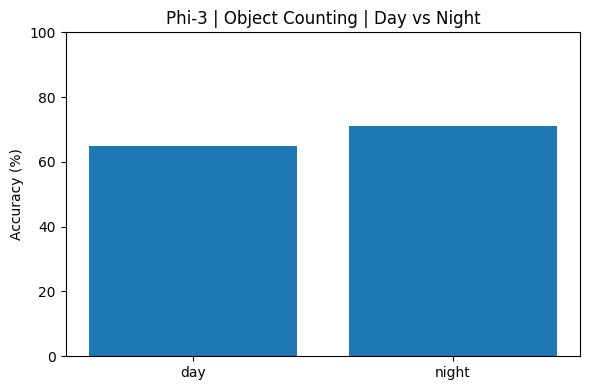

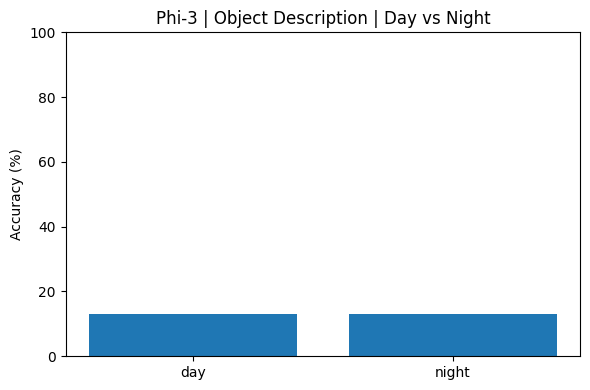

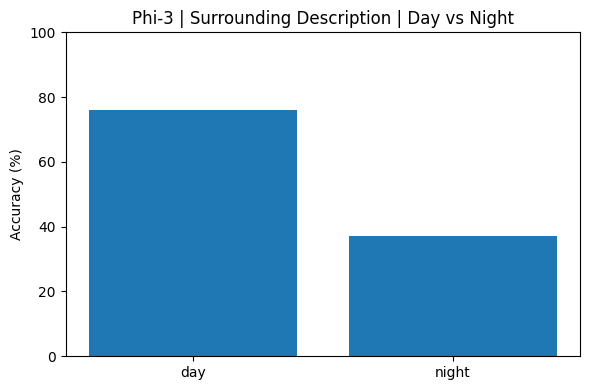

Phi charts saved


In [14]:
for category in target_categories:
    sub = phi_summary[phi_summary["category"] == category].copy()

    lights = sub["light"].tolist()
    scores = sub["accuracy_percent"].tolist()

    plt.figure(figsize=(6, 4))
    plt.bar(lights, scores)
    plt.title(f"Phi-3 | {category} | Day vs Night")
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 100)
    plt.tight_layout()

    out_png = os.path.join(
        OUTPUT_DIR,
        f"phi3_{category.replace(' ', '_').lower()}_day_night.png"
    )
    plt.savefig(out_png, dpi=200)
    plt.show()

print("Phi charts saved")

In [20]:
def load_qwen2vl():
    model_id = MODEL_IDS["qwen2vl"]

    processor = AutoProcessor.from_pretrained(model_id)

    model = Qwen2VLForConditionalGeneration.from_pretrained(
        model_id,
        torch_dtype=torch.float16,
        device_map="auto"
    )

    model.eval()
    return processor, model

def query_qwen2vl(processor, model, image_path, prompt):
    try:
        image = Image.open(image_path).convert("RGB")
        image = image.resize((448, 448))

        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text", "text": prompt},
                ],
            }
        ]

        text = processor.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

        inputs = processor(
            text=[text],
            images=[image],
            padding=True,
            return_tensors="pt"
        )

        inputs = {
            k: v.to(model.device) if hasattr(v, "to") else v
            for k, v in inputs.items()
        }

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=16,
                do_sample=False
            )

        trimmed = [
            out_ids[len(in_ids):]
            for in_ids, out_ids in zip(inputs["input_ids"], outputs)
        ]

        pred = processor.batch_decode(
            trimmed,
            skip_special_tokens=True
        )[0].strip()

        return pred.lower()

    except Exception as e:
        return f"ERROR: {e}"

In [21]:
clear_memory()
qwen_processor, qwen_model = load_qwen2vl()
print("Qwen2-VL loaded")

preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/429M [00:00<?, ?B/s]

`Qwen2VLRotaryEmbedding` can now be fully parameterized by passing the model config through the `config` argument. All other arguments will be removed in v4.46


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

Qwen2-VL loaded


In [22]:
test_row = sampled_splits[("Object Counting", "day")].iloc[0]

test_prompt = build_prompt("Object Counting", "day", test_row["question"])

pred = query_qwen2vl(
    qwen_processor,
    qwen_model,
    test_row["full_image_path"],
    test_prompt
)

print("Question:", test_row["question"])
print("Ground truth:", test_row["answer"])
print("Prediction:", pred)
print("Correct:", normalized_correct(pred, test_row["answer"], "Object Counting", test_row["question"]))

Question: How many objects of type car are in the image?
Ground truth: 5
Prediction: 1
Correct: False


In [23]:
qwen_results = []

for category in target_categories:
    for light in ["day", "night"]:
        part = sampled_splits[(category, light)].copy()

        print(f"\nRunning Qwen2-VL | {category} | {light} | samples = {len(part)}")

        for _, row in tqdm(part.iterrows(), total=len(part), desc=f"{category}-{light}"):
            question = row["question"]
            gt = row["answer"]
            image_path = row["full_image_path"]

            if not validate_question(question):
                continue

            prompt = build_prompt(category, light, question)

            pred = query_qwen2vl(
                qwen_processor,
                qwen_model,
                image_path,
                prompt
            )

            qwen_results.append({
                "model": "qwen2vl",
                "category": category,
                "light": light,
                "filename": row["filename"],
                "question": question,
                "ground_truth": gt,
                "prediction": pred,
                "is_correct": normalized_correct(pred, gt, category, question)
            })

qwen_results_df = pd.DataFrame(qwen_results)
print("Total evaluated:", len(qwen_results_df))
print(qwen_results_df.head())


Running Qwen2-VL | Object Counting | day | samples = 100


Object Counting-day:   0%|          | 0/100 [00:00<?, ?it/s]


Running Qwen2-VL | Object Counting | night | samples = 100


Object Counting-night:   0%|          | 0/100 [00:00<?, ?it/s]


Running Qwen2-VL | Object Description | day | samples = 100


...


Running Qwen2-VL | Surrounding Description | day | samples = 100


Surrounding Description-day:   0%|          | 0/100 [00:00<?, ?it/s]


Running Qwen2-VL | Surrounding Description | night | samples = 100


Surrounding Description-night:   0%|          | 0/100 [00:00<?, ?it/s]

Total evaluated: 600
     model         category light                        filename  \
0  qwen2vl  Object Counting   day  Sequence_Day_18_frame_1890.jpg   
1  qwen2vl  Object Counting   day   Sequence_Day_14_frame_540.jpg   
2  qwen2vl  Object Counting   day  Sequence_Day_18_frame_5190.jpg   
3  qwen2vl  Object Counting   day  Sequence_Day_18_frame_2490.jpg   
4  qwen2vl  Object Counting   day     Sequence_Day_8_frame_30.jpg   

                                           question ground_truth prediction  \
0    How many objects of type car are in the image?            5          1   
1    How many objects of type car are in the image?            2          1   
2                  Are there more car's than car's?           No         no   
3           Are there more car's than motorcycle's?          Yes        yes   
4  How many objects of type truck are in the image?            1          1   

   is_correct  
0       False  
1       False  
2        True  
3        True  
4        

In [24]:
qwen_summary = (
    qwen_results_df
    .groupby(["category", "light"])["is_correct"]
    .mean()
    .reset_index()
)

qwen_summary["accuracy_percent"] = (qwen_summary["is_correct"] * 100).round(2)

print(qwen_summary)

os.makedirs(OUTPUT_DIR, exist_ok=True)

qwen_results_df.to_csv(os.path.join(OUTPUT_DIR, "qwen2vl_results.csv"), index=False)
qwen_summary.to_csv(os.path.join(OUTPUT_DIR, "qwen2vl_accuracy.csv"), index=False)

print("\nQwen files saved")
print(os.listdir(OUTPUT_DIR))

                  category  light  is_correct  accuracy_percent
0          Object Counting    day        0.71              71.0
1          Object Counting  night        0.70              70.0
2       Object Description    day        0.20              20.0
3       Object Description  night        0.16              16.0
4  Surrounding Description    day        0.77              77.0
5  Surrounding Description  night        0.42              42.0

Qwen files saved
['phi3_object_description_day_night.png', 'qwen2vl_results.csv', 'phi3_results.csv', 'phi3_object_counting_day_night.png', 'phi3_accuracy.csv', 'phi3_surrounding_description_day_night.png', 'qwen2vl_accuracy.csv']


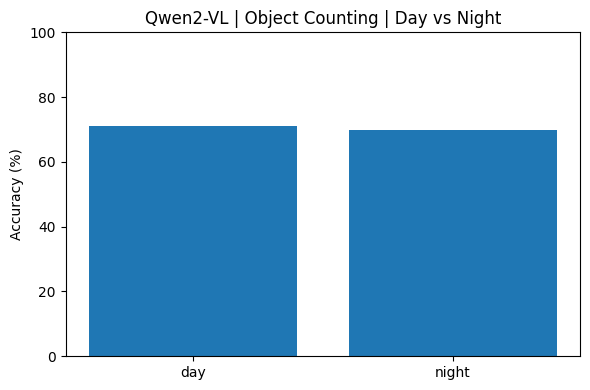

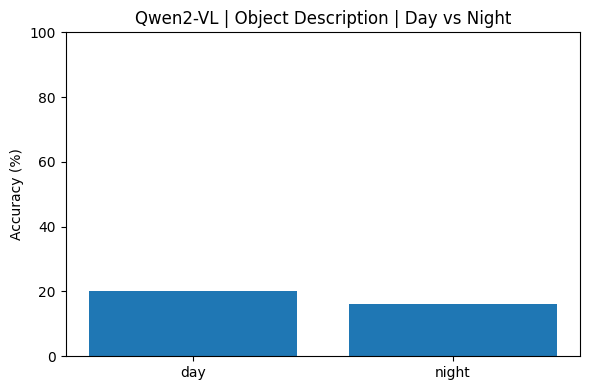

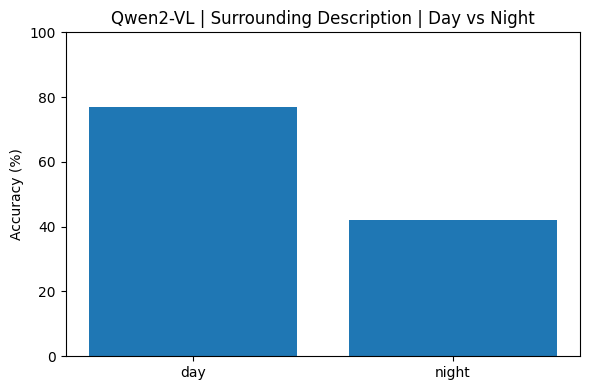

Qwen charts saved


In [25]:
for category in target_categories:
    sub = qwen_summary[qwen_summary["category"] == category].copy()

    lights = sub["light"].tolist()
    scores = sub["accuracy_percent"].tolist()

    plt.figure(figsize=(6, 4))
    plt.bar(lights, scores)
    plt.title(f"Qwen2-VL | {category} | Day vs Night")
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 100)
    plt.tight_layout()

    out_png = os.path.join(
        OUTPUT_DIR,
        f"qwen2vl_{category.replace(' ', '_').lower()}_day_night.png"
    )
    plt.savefig(out_png, dpi=200)
    plt.show()

print("Qwen charts saved")

In [26]:
compare_df = pd.concat([
    phi_summary.assign(model="phi3")[["model", "category", "light", "accuracy_percent"]],
    qwen_summary.assign(model="qwen2vl")[["model", "category", "light", "accuracy_percent"]],
], ignore_index=True)

compare_df.to_csv(os.path.join(OUTPUT_DIR, "phi3_vs_qwen2vl_comparison.csv"), index=False)

print(compare_df)
print("\nComparison saved")
print(os.listdir(OUTPUT_DIR))

      model                 category  light  accuracy_percent
0      phi3          Object Counting    day              65.0
1      phi3          Object Counting  night              71.0
2      phi3       Object Description    day              13.0
3      phi3       Object Description  night              13.0
4      phi3  Surrounding Description    day              76.0
5      phi3  Surrounding Description  night              37.0
6   qwen2vl          Object Counting    day              71.0
7   qwen2vl          Object Counting  night              70.0
8   qwen2vl       Object Description    day              20.0
9   qwen2vl       Object Description  night              16.0
10  qwen2vl  Surrounding Description    day              77.0
11  qwen2vl  Surrounding Description  night              42.0

Comparison saved
['phi3_object_description_day_night.png', 'phi3_vs_qwen2vl_comparison.csv', 'qwen2vl_results.csv', 'qwen2vl_object_description_day_night.png', 'phi3_results.csv', 'phi3_object_

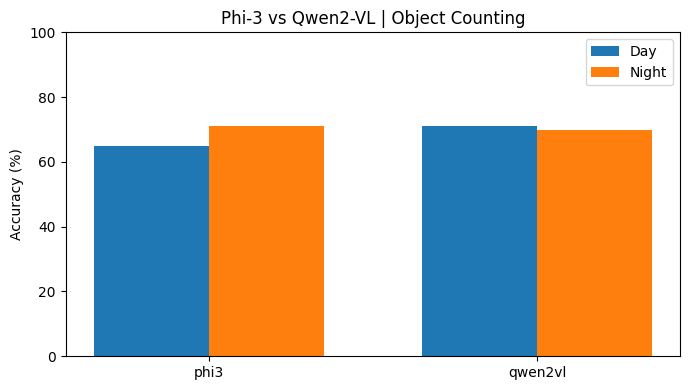

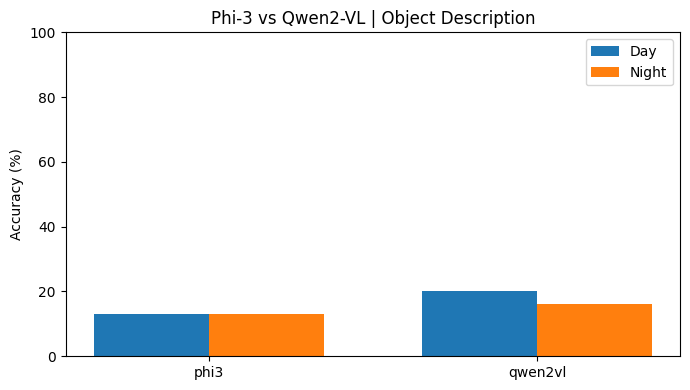

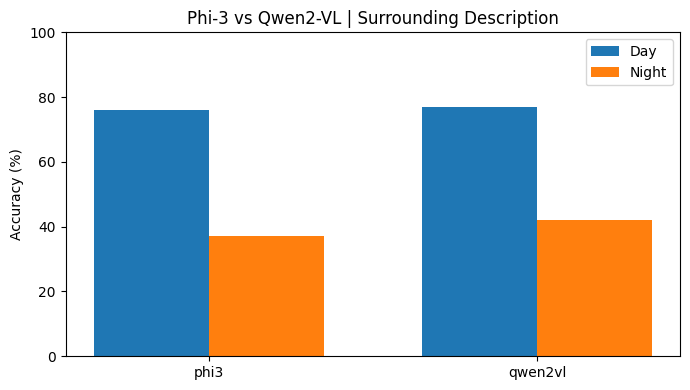

Comparison charts saved


In [27]:
for category in target_categories:
    sub = compare_df[compare_df["category"] == category].copy()

    pivot = sub.pivot(index="model", columns="light", values="accuracy_percent").reset_index()

    x = np.arange(len(pivot))
    width = 0.35

    plt.figure(figsize=(7, 4))
    plt.bar(x - width/2, pivot["day"], width, label="Day")
    plt.bar(x + width/2, pivot["night"], width, label="Night")

    plt.xticks(x, pivot["model"])
    plt.ylabel("Accuracy (%)")
    plt.title(f"Phi-3 vs Qwen2-VL | {category}")
    plt.ylim(0, 100)
    plt.legend()
    plt.tight_layout()

    out_png = os.path.join(
        OUTPUT_DIR,
        f"phi3_vs_qwen2vl_{category.replace(' ', '_').lower()}.png"
    )
    plt.savefig(out_png, dpi=200)
    plt.show()

print("Comparison charts saved")